# 🏎️ Formula Student Driverless — Notebook de Avaliação

**Aprendizagem por Reforço · Mestrado em Inteligência Artificial · Universidade do Minho · 2025/26**

**Grupo 1:** Luís Miguel Pereira Silva (PG60390) · Pedro Miguel S. A. Urbano dos Reis (PG59908)

---

Este notebook acompanha o relatório (`docs/report.pdf`) e serve para **facilitar a avaliação**: reúne, num só sítio, os resultados principais do projeto e permite **reproduzi-los ao vivo** sobre os modelos treinados.

**Como usar:** no menu, `Kernel → Restart & Run All`. As secções de resultados (3–6) usam resultados pré-computados (correm em segundos, sem GPU); as secções 2 e 7 correm um modelo treinado ao vivo (CPU, ~0.5 s/episódio).

**Índice**
0. Setup e verificação do ambiente
1. O problema e o ambiente de simulação
2. Reward shaping — como guiamos a aprendizagem
3. Resultados principais: SAC vs PPO
4. Curvas de aprendizagem (eficiência de amostras)
5. Ablações controladas
6. Viés direcional e *mirror augmentation* (descoberta principal)
7. Avaliação ao vivo de um modelo treinado
8. Como reproduzir tudo a partir da linha de comandos


## 0. Setup e verificação do ambiente

Localizamos a raiz do repositório (o notebook funciona quer seja aberto a partir de `notebooks/` quer da raiz), importamos as bibliotecas e verificamos que dependências estão disponíveis.

In [1]:
import os, sys

# --- localizar a raiz do repositório (procura results/aggregated) ---
def find_root(start):
    d = os.path.abspath(start)
    for _ in range(6):
        if os.path.isdir(os.path.join(d, "results", "aggregated")):
            return d
        d = os.path.dirname(d)
    raise RuntimeError("Não encontrei a raiz do repositório (results/aggregated).")

ROOT = find_root(os.getcwd())
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)
AGG = os.path.join(ROOT, "results", "aggregated")
print("Raiz do repositório:", ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams["figure.dpi"] = 110

# Funções de plot partilhadas com o relatório (scripts/make_report_figures.py)
from scripts.make_report_figures import (
    plot_sac_vs_ppo, plot_direction_bias, plot_ablations, _mean,
)

# Que dependências de avaliação ao vivo existem?
def _has(mod):
    try:
        __import__(mod); return True
    except Exception:
        return False
HAVE_SB3 = _has("stable_baselines3")
HAVE_ENV = _has("gymnasium")
print(f"pandas {pd.__version__} | numpy {np.__version__}")
print(f"stable-baselines3 disponível: {HAVE_SB3} | gymnasium disponível: {HAVE_ENV}")


Raiz do repositório: /home/luismpso/Documentos/github/AR2


I0000 00:00:1780501921.902320   99674 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


pandas 2.3.3 | numpy 2.3.5
stable-baselines3 disponível: True | gymnasium disponível: True


## 1. O problema e o ambiente de simulação

O agente conduz um carro de Formula Student *Driverless* numa pista delimitada por cones — **azuis** (fronteira esquerda), **amarelos** (direita) e **laranja** (partida/chegada). O ambiente (`env/racing_env.py`, API *Gymnasium*) integra:

- **Modelo cinemático de bicicleta** (~250 kg, *friction circle*, *rate limiting* no *steering*);
- **Sensor de cones** com ruído (FOV 180°, 15 m, 95 % de deteção) — o agente vê só os 3 cones mais próximos de cada cor, **sem** acesso à *centerline*;
- **14 pistas reais de competição** (formato YAML) + gerador procedural;
- **Regras FS-AI**: +2 s por cone, DOO (≥10 cones / *off-course*), *off-course* gradual.

**Observação** ∈ ℝ²⁴ (6 de estado do veículo + 18 de cones) · **Ação** ∈ [−1,1]² (*steering*, *throttle*/travão).

Abaixo visualizamos uma das pistas de teste (cones reais carregados do YAML).

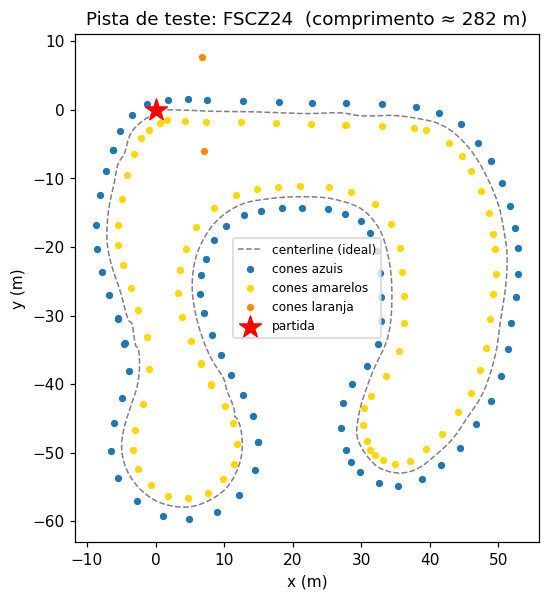

In [2]:
# Visualização de uma pista real (cones + centerline)
TRACK = "FSCZ24"   # experimenta: FSG24, FSI24, FSE24, FSS22_V2
try:
    from env.track_loader import YAMLTrackLoader
    loader = YAMLTrackLoader(os.path.join(ROOT, "tracks"))
    td = loader.load_track(name=TRACK)
    fig, ax = plt.subplots(figsize=(7, 6))
    cl = td["centerline"]
    ax.plot(cl[:, 0], cl[:, 1], "--", color="gray", lw=1, label="centerline (ideal)")
    for key, c, lab in [("blue_cones", "tab:blue", "cones azuis"),
                        ("yellow_cones", "gold", "cones amarelos"),
                        ("orange_cones", "darkorange", "cones laranja")]:
        pts = td.get(key, np.zeros((0, 2)))
        if len(pts):
            ax.scatter(pts[:, 0], pts[:, 1], s=14, color=c, label=lab)
    sp = td["start_pos"]
    ax.scatter([sp[0]], [sp[1]], marker="*", s=220, color="red", zorder=5, label="partida")
    ax.set_aspect("equal"); ax.legend(loc="best", fontsize=8)
    ax.set_title(f"Pista de teste: {TRACK}  (comprimento ≈ {td['track_length']:.0f} m)")
    ax.set_xlabel("x (m)"); ax.set_ylabel("y (m)")
    plt.show()
except Exception as e:
    print("Visualização indisponível (precisa de gymnasium/scipy):", repr(e))


## 2. Reward shaping — como guiamos a aprendizagem

A recompensa por *step* combina vários termos, cada um com um peso calibrado. O **progresso** ao longo da *centerline* é o sinal dominante; os restantes moldam um comportamento rápido, alinhado, suave e dentro da pista. Penalizações por cone (−8, ou −16 nos laranja) e o bónus de volta (+200) calibram os comportamentos-limite.

| Componente | Descrição | Peso |
|---|---|---|
| `r_progress` | distância percorrida na *centerline* (com sinal) | ×2.0 |
| `r_alignment` | v·cos(erro de *heading*) — rápido **e** alinhado | ×0.4 |
| `r_smooth` | penaliza Δ*steering* acima de *dead-band* 0.1 | ×0.05 |
| `r_lateral` | linear dentro da pista, quadrática fora | ×0.08 |
| `r_time` | custo fixo por *step* (encoraja velocidade) | −0.005 |
| *cone hit* | por cone azul/amarelo (laranja ×2) | −8 / −16 |
| *lap bonus* | por volta completa (descontado pelos cones) | +200 |

Abaixo corremos um modelo treinado numa volta e **decompomos a recompensa** nos seus componentes (mesmas fórmulas de `env/racing_env.py`): à esquerda a evolução ao longo da volta, à direita a contribuição total de cada termo no episódio. 🎬 Há também uma demonstração em vídeo em [`docs/rewardshaping.mp4`](../docs/rewardshaping.mp4).

[INFO] Carregadas 14 pistas YAML: FSCZ24, FSE22, FSE22_test, FSE23, FSE24, FSG19, FSG21, FSG23, FSG24, FSI24, FSO20, FSS19, FSS22_V1, FSS22_V2


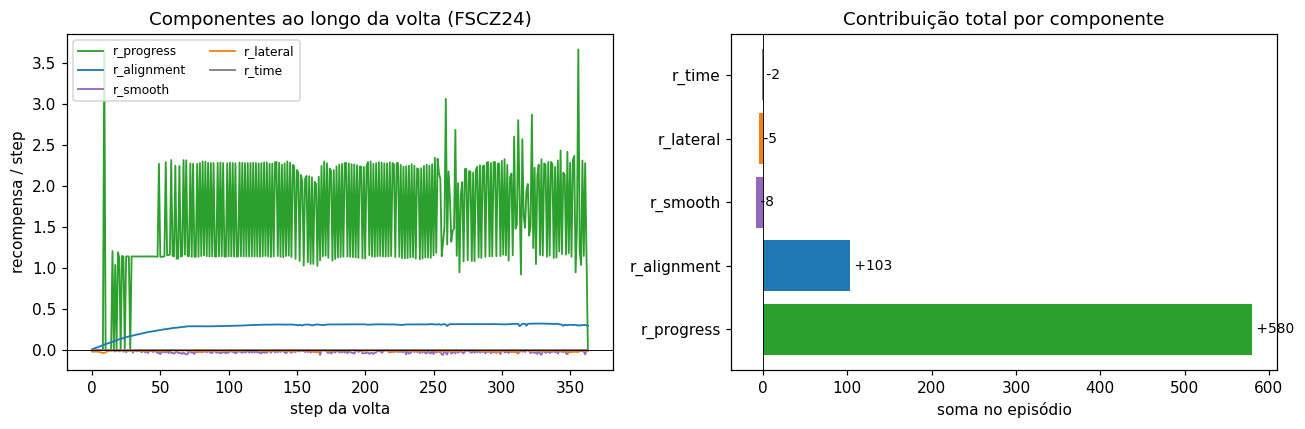

Volta FSCZ24: laps=1 | cones=1 | o progresso domina o retorno (Σr_progress ≈ +580).


In [3]:
RS_MODEL = "runs/sac_seed0/best/best_model.zip"
RS_TRACK = "FSCZ24"

def reward_components_rollout(model_path, track):
    # Corre uma volta e recompõe cada termo da reward (idêntico a _compute_reward).
    from stable_baselines3 import SAC
    from env.racing_env import FSRacingEnv
    model = SAC.load(os.path.join(ROOT, model_path), device="cpu")
    env = FSRacingEnv(render_mode=None, randomize_track=False, domain_randomization=False,
                      max_episode_steps=3000, tracks_dir=os.path.join(ROOT, "tracks"),
                      track_name=track, use_orange_cones=True, terminate_on_cone=False,
                      doo_cone_limit=999, max_laps=1)
    obs, info = env.reset(seed=0)
    vmax = env.vehicle_params.max_speed
    prev_prog, prev_steer = 0.0, 0.0
    comps = {k: [] for k in ["r_progress", "r_alignment", "r_smooth", "r_lateral", "r_time"]}
    done = False
    while not done:
        a, _ = model.predict(obs, deterministic=True)
        obs, r, term, trunc, info = env.step(a)
        done = term or trunc
        cl = env.track_data["centerline"]
        d2 = np.sum((cl - np.array([env.car.x, env.car.y]))**2, axis=1)
        cl_idx = int(np.argmin(d2))
        lateral = float(np.sqrt(d2[cl_idx]))
        hw = env._get_effective_hw()
        hdg = env._get_heading_error(cl_idx)
        raw = info["total_progress"] - prev_prog; prev_prog = info["total_progress"]
        prog = max(0.0, raw)  # ignora o reset de total_progress ao cruzar a meta
        steer = float(a[0]); ratio = lateral / (hw + 1e-6)
        comps["r_progress"].append(prog * 2.0)
        comps["r_alignment"].append((env.car.v / (vmax + 1e-6)) * np.cos(hdg) * 0.4)
        comps["r_smooth"].append(-max(0.0, abs(steer - prev_steer) - 0.1) * 0.05)
        comps["r_lateral"].append(-ratio * 0.08 if ratio <= 1.0 else -0.08 - (ratio - 1.0)**2 * 2.0)
        comps["r_time"].append(-0.005)
        prev_steer = steer
    env.close()
    return {k: np.array(v) for k, v in comps.items()}, info

if HAVE_SB3 and HAVE_ENV:
    comps, info = reward_components_rollout(RS_MODEL, RS_TRACK)
    steps = np.arange(len(comps["r_progress"]))
    colors = {"r_progress": "#2ca02c", "r_alignment": "#1f77b4", "r_smooth": "#9467bd",
              "r_lateral": "#ff7f0e", "r_time": "#7f7f7f"}
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    for k, v in comps.items():
        ax1.plot(steps, v, label=k, color=colors[k], lw=1.2)
    ax1.axhline(0, color="black", lw=0.6)
    ax1.set_xlabel("step da volta"); ax1.set_ylabel("recompensa / step")
    ax1.legend(fontsize=8, ncol=2); ax1.set_title(f"Componentes ao longo da volta ({RS_TRACK})")
    totals = {k: float(v.sum()) for k, v in comps.items()}
    ks = list(totals.keys()); vals = [totals[k] for k in ks]
    ax2.barh(ks, vals, color=[colors[k] for k in ks])
    ax2.axvline(0, color="black", lw=0.6)
    ax2.set_xlabel("soma no episódio"); ax2.set_title("Contribuição total por componente")
    for i, val in enumerate(vals):
        ax2.text(val, i, f" {val:+.0f}", va="center", fontsize=9)
    plt.tight_layout(); plt.show()
    print(f"Volta {RS_TRACK}: laps={info['laps_completed']} | cones={info['cones_hit']} | "
          f"o progresso domina o retorno (Σr_progress ≈ {totals['r_progress']:+.0f}).")
else:
    print("Secção saltada (stable-baselines3 / gymnasium em falta).")


### 🎬 Animação: a recompensa a evoluir enquanto o carro conduz

Como o vídeo da apresentação ([`docs/rewardshaping.mp4`](../docs/rewardshaping.mp4)), mas agora com a **recompensa em sincronia**: à esquerda o carro a percorrer a pista (com rasto e direção); à direita os componentes da recompensa a crescer passo-a-passo, com o cursor no *step* atual. Gerado a partir de um **rollout real** do modelo (não é desenhado à mão).

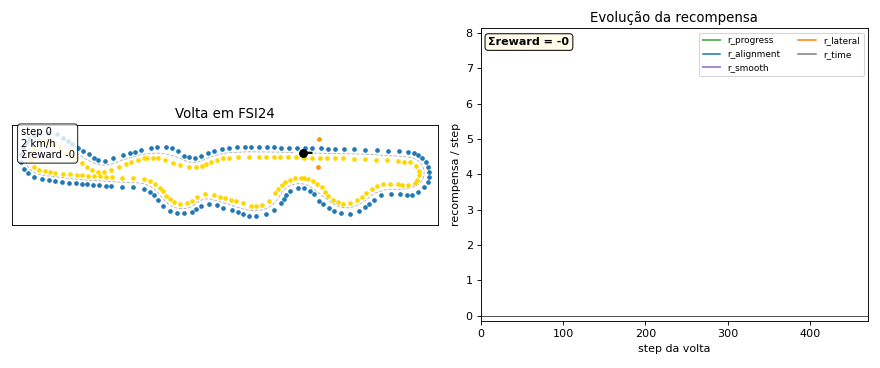

In [4]:
from IPython.display import Image as IPyImage
from scripts.make_reward_animation import make_gif

GIF = os.path.join(ROOT, "results", "figures", "reward_evolution.gif")
if HAVE_SB3 and HAVE_ENV:
    if not os.path.exists(GIF):                       # gera só se ainda não existir
        make_gif(out_path=GIF, track="FSCZ24", stride=3, fps=12)
    display(IPyImage(filename=GIF))                   # GIF embebido no notebook
else:
    print("Animação indisponível (stable-baselines3 / gymnasium em falta).")


### 🔁 O processo iterativo: como afinámos a recompensa (10 iterações)

Ao início **o carro mal se mexia**. A recompensa final foi o resultado de afinar iterativamente — cada passo a mudar *uma* coisa. Os extremos (v1 e final) são **reais** (do histórico git); a progressão completa é uma **reconstrução** treinada como estudo de design (só a recompensa varia; pista/sensor/colisão/regras ficam fixos). É o complemento *aditivo* ao estudo de ablações (secção 5, que é *subtrativo*).

| # | Mudança na recompensa | Efeito esperado |
|---|---|---|
| 1 | Só progresso (×1.0) | mal progride; sem noção de pista |
| 2 | + custo de tempo (−0.01) | não ficar parado |
| 3 | + alinhamento fraco (×0.1) | anda na direção certa, mas corta |
| 4 | reforçar progresso (×1.5) | avança mais, mas sai da pista |
| 5 | + lateral quadrática (×0.2) | fica na pista, mas conservador |
| 6 | lateral suavizada (linear dentro/quad. fora) | usa a largura da pista |
| 7 | + suavidade **sem** dead-band (−0.3·\|Δδ\|) | **regressão**: bloqueia as curvas |
| 8 | suavidade com dead-band 0.1 (×0.05) | correção: viragem normal livre |
| 9 | reescala (progr.×2.0, align×0.4, tempo−0.005) | progresso dominante; mais rápido |
| 10 | + anti-estagnação (checkpoint DOO) | sem episódios parados; **final** |

Para treinar as 10 iterações e gerar as métricas/figuras (idealmente numa GPU):
```bash
python scripts/reward_iterations.py --steps 150000 --n-envs 4 --device cuda
```
A célula abaixo mostra os resultados **se já existirem**.

In [5]:
ITER_CSV = os.path.join(ROOT, "results", "reward_iter", "metrics.csv")
if os.path.exists(ITER_CSV):
    di = pd.read_csv(ITER_CSV).sort_values("stage")
    display(di[["stage", "slug", "lap_rate", "mean_speed_kmh",
                "mean_progress_m", "frac_stationary"]].round(2))
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    specs = [("lap_rate", "Lap rate (%)", "#2ca02c"),
             ("mean_progress_m", "Progresso médio (m)", "#1f77b4"),
             ("frac_stationary", "Tempo parado (%)", "#d62728")]
    for ax, (k, lab, col) in zip(axes, specs):
        y = di[k] * 100 if k == "frac_stationary" else di[k]
        ax.plot(di["stage"], y, "o-", color=col, lw=1.8)
        ax.set_xlabel("iteração"); ax.set_ylabel(lab); ax.grid(alpha=0.3)
    axes[1].set_title("Evolução ao longo das 10 iterações de reward shaping")
    plt.tight_layout(); plt.show()
    tj = os.path.join(ROOT, "results", "figures", "reward_iter_trajectories.png")
    if os.path.exists(tj):
        from IPython.display import Image as IPyImage
        display(IPyImage(filename=tj))
else:
    print("Ainda não gerado. Corre (idealmente numa GPU):")
    print("  python scripts/reward_iterations.py --steps 150000 --n-envs 4 --device cuda")
    print("Depois re-executa este notebook para ver as métricas e figuras aqui.")


Ainda não gerado. Corre (idealmente numa GPU):
  python scripts/reward_iterations.py --steps 150000 --n-envs 4 --device cuda
Depois re-executa este notebook para ver as métricas e figuras aqui.


## 3. Resultados principais: SAC vs PPO

Comparação no **test split** (5 pistas inéditas, 10 episódios/pista, política determinística, *domain randomization* ativa). Valores $\bar{x}\pm\sigma$ entre *seeds*.

**Conclusão:** SAC e PPO têm *lap rate* equivalente (66 % vs 68 %, dentro do ruído amostral de ±5–8 pp), mas o **SAC é ~2× mais seguro** (2.4 vs 4.8 cones derrubados). O `SAC + Mirror Aug.` é o melhor compromisso global.

,model,n_seeds,lap_rate,cones,speed_kmh
0,SAC,3,66+/-0,2.4+/-0.6,76+/-1
1,PPO,3,68+/-7,4.8+/-0.9,79+/-1
2,SAC+Mirror Aug.,1,72,2.9,67


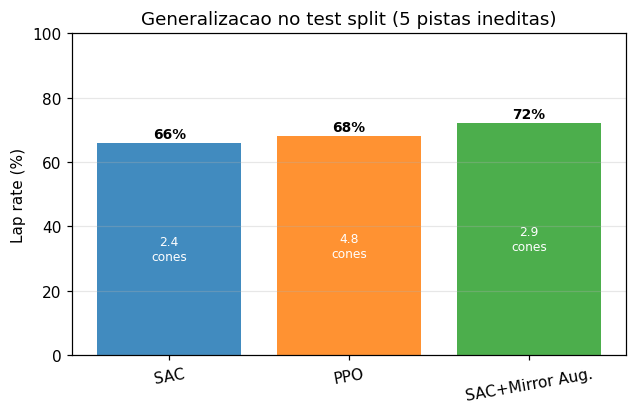

In [6]:
summary = pd.read_csv(os.path.join(AGG, "summary_main.csv"))
display(summary)

fig, ax = plt.subplots(figsize=(6.5, 3.8))
plot_sac_vs_ppo(ax=ax)   # mesma figura do relatório, desenhada inline
plt.show()


### Desempenho por pista

A dificuldade depende muito do traçado: ambos completam quase sempre FSI24/FSCZ24/FSS22_V2, mas falham em **FSE24** e **FSG24** (curvas mais apertadas) — e é aí que o PPO mais derruba cones.

In [7]:
sac_pt = pd.read_csv(os.path.join(AGG, "per_track_SAC_test.csv"))
ppo_pt = pd.read_csv(os.path.join(AGG, "per_track_PPO_test.csv"))
print("SAC — per-track (test):"); display(sac_pt)
print("PPO — per-track (test):"); display(ppo_pt)


SAC — per-track (test):


,track,lap_rate,cones,speed_kmh,laptime_s,n_seeds
0,FSG24,33+/-5,3.0+/-0.5,77.3+/-2.3,17.4+/-0.3,3
1,FSI24,97+/-5,0.4+/-0.3,81.8+/-3.4,18.3+/-0.2,3
2,FSCZ24,100+/-0,1.8+/-0.8,79.2+/-3.6,14.4+/-0.2,3
3,FSE24,7+/-9,4.5+/-1.1,67.4+/-3.2,12.8,3
4,FSS22_V2,93+/-9,2.5+/-1.1,74.2+/-1.5,7.9+/-0.1,3


PPO — per-track (test):


,track,lap_rate,cones,speed_kmh,laptime_s,n_seeds
0,FSG24,30+/-22,6.4+/-1.7,81.8+/-1.0,17.2+/-0.1,3
1,FSI24,97+/-5,0.6+/-0.4,87.2+/-0.7,17.8+/-0.2,3
2,FSCZ24,100+/-0,2.2+/-0.4,83.6+/-1.2,13.9+/-0.2,3
3,FSE24,17+/-24,10.7+/-2.3,66.2+/-4.7,13.0,3
4,FSS22_V2,97+/-5,4.2+/-1.1,76.6+/-2.0,7.7+/-0.2,3


## 4. Curvas de aprendizagem (eficiência de amostras)

Reconstruímos as curvas a partir dos `eval/evaluations.npz` de cada *run* (recompensa média de 10 episódios de avaliação, por *checkpoint*), agregando média ± desvio sobre as 3 *seeds*. O SAC (*off-policy*) atinge o plateau com ~3M *steps*; o PPO precisa de ~6M para um desempenho comparável.

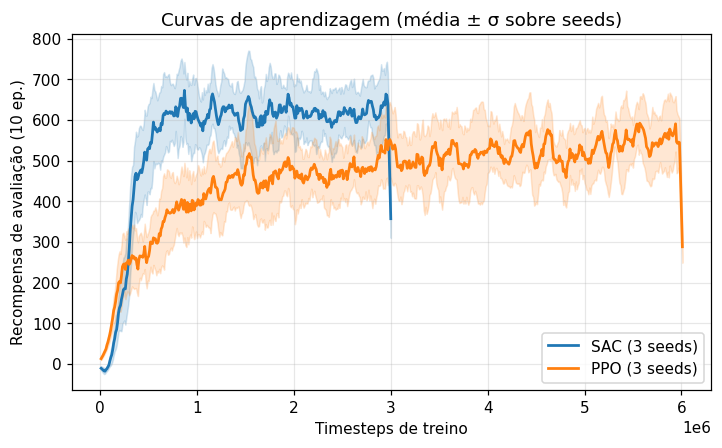

Figura agregada em alta qualidade: results/learning_curves.pdf


In [8]:
def load_eval_curve(run_dirs):
    # Média sobre seeds da recompensa de avaliação vs timesteps.
    # Cada npz tem timesteps (T,) e results (T, n_eval_eps).
    series = []
    common_ts = None
    for rd in run_dirs:
        f = os.path.join(ROOT, rd, "eval", "evaluations.npz")
        if not os.path.exists(f):
            continue
        d = np.load(f)
        ts = d["timesteps"]
        mean_per_ckpt = d["results"].mean(axis=1)
        series.append((ts, mean_per_ckpt))
    if not series:
        return None, None, None
    # alinhar pelo menor comprimento comum
    L = min(len(ts) for ts, _ in series)
    ts = series[0][0][:L]
    M = np.stack([m[:L] for _, m in series], axis=0)
    return ts, M.mean(axis=0), M.std(axis=0)

def smooth(y, k=7):
    if y is None or len(y) < k:
        return y
    return np.convolve(y, np.ones(k)/k, mode="same")

fig, ax = plt.subplots(figsize=(7.5, 4.2))
for label, runs, color in [
    ("SAC (3 seeds)", ["runs/sac_seed0","runs/sac_seed1","runs/sac_seed2"], "#1f77b4"),
    ("PPO (3 seeds)", ["runs/ppo_seed0","runs/ppo_seed1","runs/ppo_seed2"], "#ff7f0e"),
]:
    ts, mean, std = load_eval_curve(runs)
    if ts is None:
        continue
    m = smooth(mean); s = smooth(std)
    ax.plot(ts, m, color=color, label=label, lw=1.8)
    ax.fill_between(ts, m - s, m + s, color=color, alpha=0.18)
ax.set_xlabel("Timesteps de treino"); ax.set_ylabel("Recompensa de avaliação (10 ep.)")
ax.set_title("Curvas de aprendizagem (média ± σ sobre seeds)")
ax.legend(); ax.grid(alpha=0.3)
plt.show()
print("Figura agregada em alta qualidade: results/learning_curves.pdf")


## 5. Ablações controladas (SAC, 2M steps, 1 seed)

15 variantes, cada uma alterando **uma** decisão de design face a um *baseline* curto (60 % *lap rate*, 3.2 cones).

⚠️ **Ler o *lap rate* em conjunto com os cones:** algumas variantes "ganham" voltas à custa de derrubar muitos mais cones. Ex.: *Alcance 8 m* sobe para 98 % de *lap rate* mas com **16 cones** e só 52 km/h — aprende a empurrar os cones em vez de os evitar. O FOV de 180° tem um *sweet spot* não-monotónico.

,slug,category,lap_rate,cones,speed_kmh,delta_lap_pp,delta_cones
0,abl_sac_range_8,Sensor,98,16.3,52,38,13.1
1,abl_sac_fov_90,Sensor,84,9.2,71,24,6.0
2,abl_sac_fov_360,Sensor,84,17.4,79,24,14.2
3,abl_sac_no_sensor_noise,Sensor,76,4.9,76,16,1.7
4,abl_sac_batch_512,Hiperparams,74,3.2,71,14,-0.0
5,abl_sac_te_aggressive,Hiperparams,72,3.0,76,12,-0.2
6,abl_sac_no_alignment,Recompensa,68,2.7,71,8,-0.5
7,abl_sac_buffer_1M,Hiperparams,68,3.2,73,8,0.0
8,abl_sac_lr_low,Hiperparams,68,4.9,68,8,1.7
9,abl_sac_no_dr,Domain Rand.,68,4.5,77,8,1.3


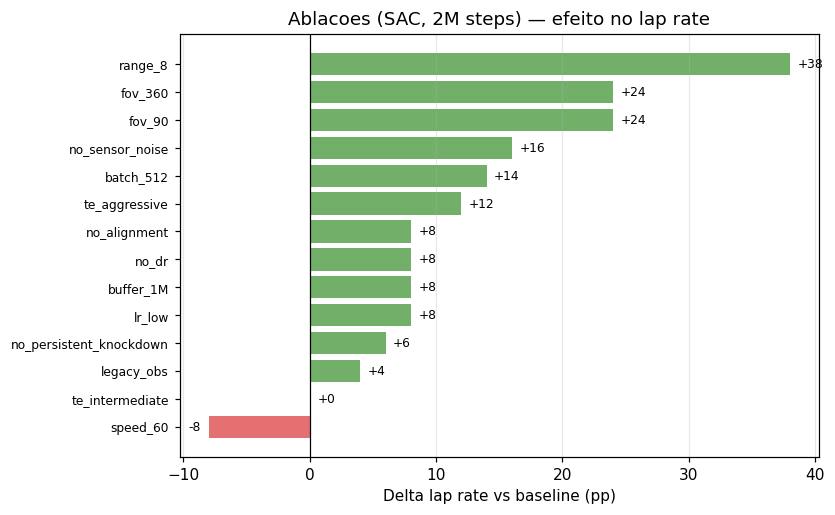

In [9]:
abl = pd.read_csv(os.path.join(AGG, "ablations.csv"))
display(abl.sort_values("delta_lap_pp", ascending=False).reset_index(drop=True))

fig, ax = plt.subplots(figsize=(7.5, 5.0))
plot_ablations(ax=ax)
plt.show()


## 6. Viés direcional e *mirror augmentation* — a descoberta principal

Avaliando os modelos em **pistas espelhadas em Y** (mesma geometria, curvas no sentido oposto — *held-out*), o *lap rate* **cai ~25 pp**: o agente sobre-ajustou a estrutura direcional do treino. Este *overfit* é **invisível** ao test split tradicional (que partilha essa estrutura).

Treinar com **mirror augmentation** (espelhar 50 % das pistas a cada *reset*) **elimina o viés**: 74 % em espelhadas (vs 40 %, **+34 pp**) e ainda melhora as originais (+6 pp), sem custo de segurança. O problema era estrutural ao treino, não ao algoritmo.

,model,test_lap_rate,mirror_lap_rate,delta_pp
0,SAC,66+/-0,40+/-11,-26
1,PPO,68+/-7,45+/-6,-23
2,SAC+Mirror Aug.,72,74,2


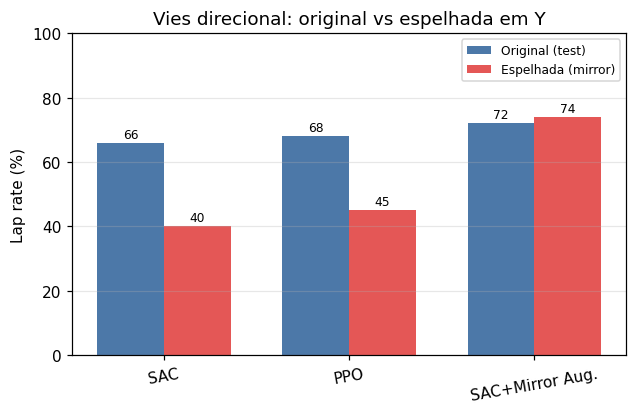

In [10]:
bias = pd.read_csv(os.path.join(AGG, "summary_direction_bias.csv"))
display(bias)

fig, ax = plt.subplots(figsize=(6.5, 3.8))
plot_direction_bias(ax=ax)
plt.show()


## 7. Avaliação ao vivo de um modelo treinado

Carregamos um modelo treinado (Stable-Baselines3) e corremos episódios **headless** (sem render) numa pista do test split, imprimindo as métricas FS-AI. Corre em CPU (~0.5 s/episódio).

> Põe `RUN_LIVE = False` para saltar esta secção. Para **ver** o carro a conduzir (janela PyGame), corre no terminal:
> `python evaluate.py --mode sb3 --model runs/sac_seed0/best/best_model.zip --track FSCZ24 --n-episodes 3`

In [11]:
RUN_LIVE = True            # põe False para saltar
MODEL = "runs/sac_seed0/best/best_model.zip"
ALGO  = "sac"              # 'sac' ou 'ppo'
TRACKS = ["FSCZ24", "FSI24", "FSS22_V2"]   # subconjunto do test split
N_EPISODES = 3

def eval_live(model_path, algo, tracks, n_episodes=3):
    from stable_baselines3 import SAC, PPO
    from env.racing_env import FSRacingEnv
    Model = SAC if algo == "sac" else PPO
    model = Model.load(os.path.join(ROOT, model_path), device="cpu")
    rows = []
    for tr in tracks:
        env = FSRacingEnv(render_mode=None, randomize_track=False,
                          domain_randomization=True, max_episode_steps=3000,
                          tracks_dir=os.path.join(ROOT, "tracks"), track_name=tr,
                          use_orange_cones=True, terminate_on_cone=False,
                          doo_cone_limit=999, max_laps=1)
        laps, cones, speeds, rewards = [], [], [], []
        for ep in range(n_episodes):
            obs, info = env.reset(seed=ep)
            done = False; R = 0.0
            while not done:
                a, _ = model.predict(obs, deterministic=True)
                obs, r, term, trunc, info = env.step(a)
                done = term or trunc; R += r
            laps.append(info["laps_completed"]); cones.append(info["cones_hit"])
            speeds.append(info["speed_kmh"]); rewards.append(R)
        env.close()
        rows.append({"pista": tr,
                     "lap_rate_%": 100.0 * np.mean([l >= 1 for l in laps]),
                     "cones_méd": np.mean(cones),
                     "vel_méd_kmh": np.mean(speeds),
                     "reward_méd": np.mean(rewards)})
    return pd.DataFrame(rows)

if RUN_LIVE and HAVE_SB3 and HAVE_ENV:
    df_live = eval_live(MODEL, ALGO, TRACKS, N_EPISODES)
    display(df_live.round(1))
    print(f"\nModelo: {MODEL} | {N_EPISODES} episódios/pista | domain randomization ativa")
else:
    print("Secção saltada (RUN_LIVE=False ou dependências em falta).")


[INFO] Carregadas 14 pistas YAML: FSCZ24, FSE22, FSE22_test, FSE23, FSE24, FSG19, FSG21, FSG23, FSG24, FSI24, FSO20, FSS19, FSS22_V1, FSS22_V2


[INFO] Carregadas 14 pistas YAML: FSCZ24, FSE22, FSE22_test, FSE23, FSE24, FSG19, FSG21, FSG23, FSG24, FSI24, FSO20, FSS19, FSS22_V1, FSS22_V2


[INFO] Carregadas 14 pistas YAML: FSCZ24, FSE22, FSE22_test, FSE23, FSE24, FSG19, FSG21, FSG23, FSG24, FSI24, FSO20, FSS19, FSS22_V1, FSS22_V2


,pista,lap_rate_%,cones_méd,vel_méd_kmh,reward_méd
0,FSCZ24,100.0,1.0,78.2,855.6
1,FSI24,100.0,0.0,77.9,1084.7
2,FSS22_V2,66.7,1.7,71.6,387.8



Modelo: runs/sac_seed0/best/best_model.zip | 3 episódios/pista | domain randomization ativa


## 8. Como reproduzir tudo a partir da linha de comandos

```bash
# Instalar dependências
pip install -r requirements.txt

# Testes unitários (ambiente, modelo de veículo, splits)
pytest -q

# Treino SAC (3M steps) e PPO (6M steps) — requer GPU
python train.py --mode sb3 --algo sac --total-steps 3000000 --split train --seed 0 --run-name sac_seed0
python train.py --mode sb3 --algo ppo --total-steps 6000000 --split train --seed 0 --run-name ppo_seed0

# SAC com mirror augmentation (corrige o viés direcional)
python train.py --mode sb3 --algo sac --total-steps 3000000 --split train --seed 0 --mirror-augment --run-name sac_mirror_aug

# Avaliação per-track (gera CSV + tabela LaTeX)
python scripts/eval_per_track.py --model runs/sac_seed0/best/best_model.zip --algo sac --split test --n-episodes 10

# Visualização PyGame (ver o carro a conduzir)
python evaluate.py --mode sb3 --model runs/sac_seed0/best/best_model.zip --track FSCZ24 --n-episodes 3

# Regenerar as figuras deste notebook / do relatório
python scripts/make_report_figures.py
```

---
O relatório completo está em [`docs/report.pdf`](../docs/report.pdf). Detalhes de arquitetura e de cada componente estão no [`README.md`](../README.md).